# 개요

### MPP: Muse Pulse Project

1. **(프로젝트 목표)** AI를 이용해 우리나라 주식 시장에서 주식이 오르가나 떨어지는 구간의 패턴을 파악하고 해당 시점에 주식을 매도나 매수할 수 있는 주식거래 자동화 시스템(MPS, Muse Pulse System)을 설계하는 프로젝트

1. **(MP, Muse Pulse 란?)** 시장 참여자의 뮤즈(muse, 아이디어·심리·의도)에서 살아있는 펄스(pulse, 맥박·맥락)을 짚어낸다는 의미로, `참여자의 심리를 바로 찾아 거래를 주도한다`는 의미임

1. **(Version)** 1.0, 
1. **(Last updated)** 2026-04-30 18:13 freeman.cho@gamil.com

### 배경 및 필요성

현대 주식시장은 개인 투자자가 감당하기 어려운 속도와 복잡성을 지니고 있으며, 방대한 정보량과 빠른 변화 속도는 이미 인간의 인지 한계를 넘어섰다. 이로 인해 다음과 같은 구조적 문제가 발생한다.

1. **(정보의 폭증)** 국내 주식시장만 해도 코스피·코스닥에 2,500개 이상의 종목이 상장되어 있고, 매 거래일마다 수천건의 뉴스·공시·거시지표가 쏟아진다. 개인이 이 모든 정보를 실시간으로 파악하는 것은 물리적으로 불가능함.

1. **(반응 속도의 한계)** 호재·악재가 발생한 순간부터 주가에 반영되기까지의 시간은 점점 짧아지고 있다. 알고리즘 거래·기관 투자자가 수 밀리초 단위로 반응하는 환경에서, 사람이 뉴스를 읽고 판단해 주문을 넣는 속도로는 기회를 잡기 어려움.

1. **(감정적 판단의 개입)** 인간은 손실 회피 편향, 확증 편향, 군중 심리 등 감정적 요인에서 자유로울 수 없다. 같은 데이터를 보고도 그날의 컨디션이나 직전의 손익에 따라 다른 결정을 내린다.

1. **(일관된 분석의 어려움)** 개인이 매일 동일한 기준으로 전 종목을 스캔하고, 동일한 매매 규칙을 적용하기란 사실상 불가능. 시스템에 의한 자동화는 일관성을 확보하는 가장 효과적인 수단임

이러한 한계들을 해결하려면, 데이터 수집부터 신호 탐지·주문 실행까지 전 과정을 자동화한 시스템이 필요함.

### 목표 및 주요 기능

1. **(목표)** 시장의 변화를 사전에 감지하여 적절한 매수·매도 타이밍을 포착하고, 이를 통해 주식 거래에서 손실을 최소화하고 수익 기회를 놓치지 않는 단타(데이트레이딩) 자동매매 시스템 확보

1. **(주요 기능)**
    - **(사전 감지)** 가격이 이미 움직인 후 따라가는 것이 아니라, 움직임의 전조를 데이터에서 미리 포착
    - **(타이밍 포착)** 매수·매도 시점을 객관적 기준에 따라 결정하여 진입·청산 시점의 자의성 제거
    - **(손실 최소화)** 잘못된 판단의 손실을 시스템이 자체적 리스크 관리를 통해 통제
    - **(기회 비용 축소)** 사람이 놓치는 시간대(장 시작 직후, 점심시간, 마감 직전 등)에도 시스템이 지속적으로 시장을 감시

### 프로젝트 범위

1. **(시장 범위)** 국내 주식시장(KOSPI)으로 한정. 국내 시장은 거래시간·결재구조·세금·공시체계가 통일되어 있어 시스템 설계의 일관성을 확보하기 쉽고, KIS Open API 등 자동매매 인프라도 잘 갖춰져 있음

1. **(종목 범위)** 
    - **(추천 방향)** `단일 종목`에서 `전 종목`으로 확장하는 접근법 사용 
    - **(추천 사유)**
        - **(변수 통제)** 초기에는 모델·피처·라벨링 전략 자체가 검증되지 않은 상태로, 종목까지 변수에 추가하면 무엇이 문제인지 진단하기 어려움
        - **(확장 경로가 명확)** 단일 종목 ⇒ 동일 섹터 다종목 ⇒ KOSPI 200 ⇒ 전 종목 순으로 단계적 확장이 가능함
        - **(거래량·유동성 확보)** 대형주는 슬리피지<small>(기대한 가격과 체결된 가격의 차이)</small>가 적고 호가가 촘촘해 백테스트와 실거래 간 괴리가 적음
    - **(단계별 종목 수)**
        - **(1단계, 단기)** 삼성전자 등 대형주 1~3종목으로 모델링·백테스트 검증
        - **(2단계, 중기)** KOSPI 200 우량주로 확장하며, 종목별 일반화 성능 평가
        - **(3단계, 장기)** 전 종목 스캐닝 시스템으로 전환, 신호 강도 상위 종목 선별 매매

# 시스템 철학 및 설계 원칙

### 시스템 철학

MPS(Muse Pulse System)은 단타(데이트레이딩) 자동매매 시스템으로, 당일 진입·당일 청산을 원칙으로 하며, 분봉 단위 데이터에서 매매 타이밍을 포착하고, 다음과 같은 특수성을 가짐

1. **(시간 압박)** 신호 발생부터 주문 집행까지 수 초 ~ 수 분 이내 완료 필요
1. **(거래 빈도 다수)** 하루 수 회 ~ 수십 회 거래로 누적 수수료 및 세금 영향이 큼
1. **(노이즈 위험)** 분 단위 데이터는 일봉 대비 노이즈 비율이 높음
1. **(변동성 큼)** 시가·점심·마감 시간대별로 시장 특성이 크게 다름

또한, MPS는 숫자 기반 통계 모델링에만 의존하지 않고, 분봉 차트의 형태·움직임·시각적 패턴 자체에서도 매매 신호를 찾아내며, 트레이더가 차트를 보고 "지금이 진입 시점"이라고 판단하는 그 인지 과정을 시스템화한다. 따라서 수치 분석과 패턴 인식이라는 두 축이 MPS의 신호 생성을 관리한다.

이러한 단타·이중 분석 구조의 자동매매 시스템에서는 "성능이 좋은가"보다 "신뢰할 수 있고 빠른가"가 더 중요한 판단 기준이 됨.

### 시스템 설계 원칙

MPS(Muse Pulse System)은 다음과 같은 가정 위에서 동작하며, 이 가정이 깨지면 시스템의 신뢰성이 무너지므로, 모든 모듈은 이를 위배하지 않도록 설계.

1. **미래 정보 차단 (No Look-ahead Bias)** <br/> 어떠 시점의 예측·판단에는 해당 시점 이전에 실제로 관측 가능했던 정보만 사용한다. 분봉 데이터에서는 특히 봉 완성 시점을 엄격히 다룬다. 09:31:00 시점의 신호는 09:30 봉이 완성된 이후에만 산출 가능하며, 09:30 봉의 종가를 09:30:30에 사용해서는 안된다. 패턴 인식에서도 마찬가지로, "지금 형성 중인 봉"의 형태는 봉이 완성되기 전까지 패턴 판정에 사용하지 않는다.

1. **모의투자 우선 검증 (Paper Trading First)** <br/> 실계좌 연결은 모의투자 환경에서 최소 검증 기간을 통과한 이후에만 허용하며, 단타는 거래 빈도가 높아 잘못된 시스템이 짧은 시간에 큰 손실을 누적시킬 수 있으므로, 백테스트, 모의투자, 실계좌의 3단계 게이트를 더욱 엄격히 적용함. 각 단계는 명시적 승인 기준(승률·손익비·최대낙폭 등)을 통과해야 다음 단계로 넘어감

1. **거래는 보수적으로 수행 (Conservative Cost Modeling)** <br/> 단타에서 거래 비용은 시스템의 생존 여부를 결정. 수수료(매수·매도 약 0.015%*2)·증권거래세(매도 0.18%)·슬리피지·체결 실패 가능성을 항상 보수적으로 가정하고, 종목당 1회 왕복 거래 시 최소 0.25% 이상의 비용을 가정하고 신호 임계값을 설정한다.

1. **모델은 틀릴 수 있다, 그것도 자주 (Model is Fallible)** <br/> 단타 신호의 승률은 일반적으로 50~60% 수준에 머물며, 손익비로 수익을 만드는 구조임. 어떤 모델도 100% 맞지 않으며, 장중 레짐(추세장 vs 횡보장 vs 변동성 증폭)이 바뀌면 모델 성능이 급변함. 따라서 시스템은 모델의 정확도와 무관하게 리스크 관리 계층이 손실을 통제할 수 있어야 함.

1. **당일 청산 원칙 (Intraday Close-out)** <br/> 모든 포지션은 장 마감 전까지 청산하는 것을 기본 원칙으로 한다. 익일 갭(gap) 리스크와 미체결 포지션의 오버나잇 변수를 시스템 설계에서 제거하고, 청산 실패시 자동으로 마감 직전 시장가 청산을 트리거함.

1. **차트는 데이터가 아닌 신호다 (Chart as a First-Class Signal)** <br/> MPS는 분봉 차트의 시각적 형태·움직임 자체를 1급 신호원으로 다룬다. 즉 차트는 "수치 데이터를 보여주는 보조도구"가 아니라 그 자체가 분석 대상이다. <br/> 이는 다음을 함의한다.
    - 캔들 형태(망치형·도지·장대양봉·꼬리 길이 등)는 수치 피처와 동등한 입력이 됨
    - 봉의 연속 패턴(쌍봉·해드앤숄더·삼각수렴·박스권 돌파 등)이 신호 트리거가 될 수 있음
    - 거래량의 시각적 분포(거래량 폭증, 매물대 형성 등)도 패턴으로 인식
    - 차트 이미지를 직접 입력으로 받는 비전 모델 활용을 배제하지 않음

1. **수치와 패턴은 서로를 검증한다 (Cross-Verification)** <br/> 수치 분석과 패턴 인식은 독립적으로 신호를 생성하고, 합의(confluence) 될 때 신뢰도가 높아진다는 가정을 따른다. 같은 시점에 수치 모델이 매수 신호를 내고 패턴 인식이 상승 패턴을 발견하면, 두 신호가 서로의 잡음을 걸러내는 역할을 한다. 단일 축에만 의존하면 그 축의 약점에 그대로 노출된다.

1. **재현 가능성 (Reproducibility)** <br/> 동일한 데이터·코드·시드로 동일한 결과가 재현되어야 한다. 데이터 버전·모델 비전·코드 커밋이 모두 추적 가능해야 하며, "그때는 됐는데, 지금은 안 된다"는 상황을 허용하지 않음.

1. **관측 가능성 (Observable by Default)** <br/> 시스템이 어떤 판단을 왜 내렸는지 사후에 추적 가능해야한다. 모든 신호·주문·체결은 로그로 남고, 모델의 예측 근거(어떤 피처가 기여했는지)도 기록한다. "블랙박스가 알아서 잘 하겠지"는 허용하지 않음.

1. **지연시간은 곧 비용 (Latency is Cost)** <br/> 신호 발생부터 주문 제출까지 지연 시간은 슬리피지로 직결되며, 시스템은 추론 지연·네트워크 지연·주문 처리 지연을 각각 측정하고, 합산 지연이 임계값을 넘으면 해당 신호를 폐기한다. 패턴 인식 모델이 수치 모델보다 무거울 가능성이 높으므로, 두 모델의 추론 지연을 별도로 관리한다.

### 트레이드오프(Trade-Off) 결정 들

설계 과정에서 내린 주요 결정으로, **대안**에 표시된 내용은 포기한 내용에 대한 다른 생각인것이지 이 시스템에서 대안을 채용한다는 의미는 아님.

1. **(결정1) 매매 시간 스케일**
    - **(선택)** 단타(분봉 단위 신호, 당일 진입·당일 청산)
    - **(근거)** 초단타는 ms 단위 인프라(콜로케이션·전용선)와 시장조성자 수준의 자본력이 필요해 개인 시스템으로 구현 불가. 단기 스윙은 오버나잇 갭 리스크와 야간 글로벌 이슈 노출이 커 자동 매매로 통제하기 어려움. 단타는 개인 인프라로 구현 가능하면서도 일관된 매매 규칙 적용 효과를 가장 잘 누릴 수 있는 영역임
    - **(포기)** 초단타의 고빈도 수익 기회, 스윙의 장기 추세 추종 효과 등
    - **(대안)** 초단타(스캘핑, 초~분단위), 단기 스윙(수일~수주)

1. **(결정2) 신호 생성 구조**
    - **(선택)** 수치 모델과 패턴 인식을 독립 모듈로 운영하고, 신호 합의(confluence) 단계에서 결합
    - **(근거)** 두 접근은 본질적으로 다른 정보를 추출하며, 수치 모델은 통계적 관계와 정량적 임계값에 강하고, 패턴 인식은 형태적 맥락(추세 전환·지지저항·거래량 분포)에 강함. 이를 처음부터 단일 모델로 합치면 어느 쪽 정보가 부족한지 진단하기 어려우니 독립 모듈로 운영하면 각자의 성능을 별도로 측정할 수 있고, 한 축이 실패할 때 다른 축이 안전망이 될 수 있음.
    - **(포기)** 통합 모듈이 줄 수 있는 종단간(ent-to-end) 최적화 효과. 추후 두 축의 거동을 충분히 이해한 후 통합 모델로 발전 가능성 열어둠
    - **(대안)** 수치 모델 단독, 패턴 인식 단독, 단일 멀티모달 모델로 통합

1. **(결정3) 데이터 해상도 및 룩백 윈도우**
    - **(선택)** 1분봉 기준 120~240분 룩백 (직전 2~4시간 데이터)
    - **(근거)** 룩백 윈도우는 예측 시간 스케일에 비례해야 함. 단타 보유 시간이 수십분~수시간이므로 룩백도 같은 스케일이 자연스러움. 1분봉은 충분한 해상도와 합리적 데이터량의 균형점이며, 한국 시장 정규 거래시간(09:00~15:30)이 약 390분이므로 120~240분 윈도우는 직전 거래일 후반부+당일 누적 데이터를 포함할 수 있는 길이임. 패턴 인식 관점에서도 120~240봉은 주요 차트 패턴(쌍봉·헤드앤숄더·박스권 등)이 형성되기에 충분
    - **(포기)** 틱 데이터의 미세 호가 정보, 일봉이 제공하는 중기 추세 맥락. 일봉 추세는 별도 보조 피처로 통합 검토
    - **(대안)** 일봉 60일, 5분봉 1~3일, 틱 데이터 수천 틱

1. **(결정4) 패턴 인식 접근**
    - **(선택)** 명시적 룰(캔들 패턴·기본 차트 패턴)과 학습 기반(CNN 또는 1D-CNN/시계열 트랜스포머)을 병행
    - **(근거)** 룰 기반은 해석 가능성이 높고 즉시 작동 가능하나 표현력이 제한적, 학습 기반은 표현력이 높으나 충분한 라벨 데이터가 필요하고 해석이 어려움. 초기에는 룰 기반으로 신호 후보를 생성하면서 학습 기반 모델을 점진적으로 강화하는 단계적 접근이 위험을 분산. 두 접근의 합의가 일치할 때 신호 강도를 가산
    - **(포기)** 단일 접근이 줄 수 있는 단순성. 두 시스템을 동시에 유지·평가하는 운영 비용 증가
    - **(대안)** 전통적 캔들스틱 룰만 사용, CNN/Vision Transformer 단독, 시계열 패턴 매칭(DTW 등) 단독

1. **(결정5) 패턴 인식 입력 형태**
    - **(선택)** 1차로 정규화된 OHLCV 시계열을 1D-CNN/시계열 트랜스포머에 입력, 2차로 차트 이미지를 비전 모델에 입력하는 이중 표현
    - **(근거)** 시계열 수치 입력은 가볍고 빠르며 모델이 봉의 정확한 값을 직접 학습할 수 있음. 차트 이미지 입력은 인간 트레이더가 보는 것과 동일한 시각적 맥락(추세선·지지저항·거래량 분포의 시각적 합성)을 제공. 두 표현은 상호 보완적이며 호가창 이미지는 데이터 수집 부담이 커 초기에는 제외.
    - **(포기)** 호가 미시구조 정보, 입력 표현 단순화의 이점
    - **(대안)** 시계열 수치만 입력, 차트 이미지만 입력, 호가창 이미지 포함

1. **(결정6) 라벨링**
    - **(선택)** Triple Barrier - 익절선·손절선·시간만료 중 먼저 닿는 것을 라벨로 사용. 임계값은 단타 스케일로 재설정
    - **(근거)** 실제 매매는 "방향이 맞았는가"가 아니라 "익절·손절·시간만료 중 무엇이 먼저 도달했는가"의 문제로 패턴 인식 모델도 동일한 라벨을 공유하면 두 축의 출력이 직접 비교·결합 가능
        - **(초기 임계값)** 익절 +0.5%, 손절 -0.3%, 시간 만료 60분. 백테스트를 통해 종목별 최적값 탐색 필요
    - **(포기)** 라벨 생성 복잡도 증가, 임계값 자체가 추가 하이퍼파라미터가 됨
    - **(대안)** 단순 방향 분류, N분 후 수익률 회귀, 패턴 종류별 분류

1. **(결정7) 정규화**
    - **(선택)** 수치 트랙은 직전 N분 윈도우의 롤링 Z-score, 패턴 트랙은 윈도우 내 최저~최고가를 0~1로 매핑하는 상대 정규화
    - **(근거)** 단타는 장중 시간대별 가격·거래량 분포가 크게 다름. 수치 트랙의 롤링 z-score는 "지금 이 시점의 평소 대비 비정상도"를 표현하며, 패턴 트랙은 절대 가격이 아닌 형태가 핵심이므로, 윈도우 내 상대 위치로 정규화해야 종목·가각대와 무관하게 동일 패턴을 인식할 수 있음.
    - **(포기)** 두 트랙의 정규화 방식 통일이 주는 단순성. 트랙 간 출력 결합 시 추가 정합 작업 필요
    - **(대안)** 전체 학습 구간 통계 기반 z-score, 정규화 생략, 패턴 트랙도 z-score 사용

1. **(결정8) 데이터 분할**
    - **(선택)** 거래일을 단위로 시간순 70/15/15 분할 + 위크포워드 검증
    - **(근거)** 시계열 데이터의 무작위 분할은 미래 정보 누출의 직접적 원인. 분봉 단위 분할은 같은 날 데이터가 학습·검증에 섞여 누출 발생. 패턴은 종종 여러 봉에 걸쳐 형성되므로, 분봉 단위 분할 시 같은 패턴이 학습·검증에 쪼개져 들어갈 수 있음. 거래일 단위 분할은 이를 방지함.
    - **(포기)** 일반적 K-fold가 주는 통계적 안정성. 위크포워드와 다중 시드 평균으로 보완
    - **(대안)** 분봉 단위 무작위 분할, 무작위 K-fold, 패턴 단위 분할

1. **(결정9) 시작 종목**
    - **(선택)** 단일 대형주(삼성전자)로 시작
    - **(근거)** 초기에는 모델·피처·라벨링 전략과 패턴 인식 모델까지 모두 검증되지 않은 상태로 종목까지 변수에 추가하면 문제 진단이 어려워짐. 삼성전자는 분봉 거래량이 풍부해 슬리피지 영향이 작고, 호가가 촘촘해 백테스트와 실시간 괴리가 적음. 패턴 인식 학습 데이터로서도 거래일 수가 많고 다양한 시장 레짐을 경험한 종목
    - **(포기)** 초기 단계의 종목 분산 효과, 일반화 검증. 3단계(전 종목으로 대상 확대) 이후 종목 점진 확장
    - **(대안)** 처음부터 다종목, KOSPI 200 전체, 거래량 상위 N개 동적 선정

1. **(결정10) 시장 범위**
    - **(선택)** KOSPI(국내 주식) 한정
    - **(근거)** 거래 시간·세금·결제·공시 체계가 통일되어 시스템 설계 일관성 확보 가능. KIS Open API의 분봉 실시간 스트리밍 지원이 단타에 적합. 국내 시장 거래시간(09:00~15:30)이 한정적이어서 시스템 운영·모니터링 부담이 합리적
    - **(포기)** 글로벌 분산투자 효과, 24시간 거래 환경의 학습 기회
    - **(대안)** 미국 주식 병형, 글로벌 멀티 마켓

1. **(결정11) 청산 정책**
    - **(선택)** 장 마감 10~15분 전 미청산 포지션 강제 청산
    - **(근거)** 오버나잇 갭 리스크는 단타 모델이 학습하지 않는 변수로 미국 시장 야간 흐름·아시아 다른 시장 영향·한국 시장 회 뉴스 등 통제 불가능한 요인에 노출되며, 강제 청산은 시스템의 가정과 실거래를 이치시키는 안전 장치임.
    - **(포기)** 강한 추세를 다음 날까지 끌고 갈 수 있는 기회. 이는 단타 시스템의 책임 영역 밖이라는 판단
    - **(대안)** 익일까지 보유 허용, 익절·손절 선만으로 자율 청산

##### 변경할 수 없는 것

이 원칙은 시스템의 정체정을 정의하며, 이를 흔드는 결정은 사실상 새로운 프로젝트의 시작임.

1. 미래 정보 차단(look-ahead bias 금지) 원칙
1. 모의투자 단계를 거친 후에만 실계좌 연결
1. 보수적 거래 비용 모델링
1. 리스크 관리 계층의 독립성 (모델·패턴 인식과 분리된 별도 가드레일)
1. 모든 신호·주문·체결의 로그 기록 (패턴 신호의 차트 스냅샷 포함)
1. 재현 가능성 보장 (데이터·모델·코드 비전 추적)
1. 단타(데이트레이딩) 매매 스타일 - 당일 진입·당일 청산 원칙
1. 수치 분석과 패턴 인식의 이중 트랙 신호 생성 구조
1. 국내 주시시장 범위


##### 변경할 수 있는 것

근거가 있을 때 변경 가능하며, 변경 시에는 결정 기록에 추가

1. 룩백 윈도우 길이 (120분 ⇒ 종목·시간대별 가변 가능)
1. Triple Barrier의 임계값 (익절·손절·시간만료 비율)
1. 데이터 해상도 (1분봉 ⇒ 5분봉 또는 30초봉 혼용)
1. 정규화 방식 (트랙별 정규화 방식 변경 가능)
1. 패턴 인식 알고리즘 (룰 기반 비중, CNN/트랜스포머 구조)
1. 차트 이미지 표현 방식 (캔들 차트 ⇒ 라인 차트 + 거래량, 색상·해상도 등)
1. 두 트랙의 신호 결합 방식 (가중 평균 ⇒ 메타 모델 ⇒ 강화학습 정책)
1. 사용 종목 범위 (단일 ⇒ 거래량 상위 N개 ⇒ 동적 종목 풀)
1. 모델 아키텍처 (LSTM ⇒ Transformer ⇒ 앙상블)
1. 데이터 소스 추가·교체 (분봉 + 호가 + 뉴스 + 공시 등)
1. 백테스트 엔진 선택 (자체 구현 ⇔ 라이브러리)
1. 신호 발생 빈도 (분당 1회 ⇒ 봉 완성 시마다 ⇒ 호가 변화 트리거)
1. 강제 청산 시점 (마감 15분전 ⇒ 종목별 가변)


##### 반드시 변경될 것

처음부터 "임시"임을 인정하고 추상화 형태로 설계. 여기에 의존하는 코드는 교체 비용이 높아지므로 인터페이스 형태로 격리

1. 초기 모의 데이터·시뮬레이터 ⇒ 실시간 분봉 스트리밍 파이프라인 완성 시 폐기
1. 단일 종목(삼성전자) 하드 코딩 ⇒ 종목 풀 시스템으로 전환
1. 단순 임계값 기반 신호 ⇒ 모델·패턴 기반 신호
1. 룰 기반 패턴 인식 ⇒ 학습 기반 패턴 인식 비중 증가
1. 정적 차트 이미지 생성 ⇒ 실시간 차트 텐서 변환 파이프라인
1. 일괄 추론 (batch inference) ⇒ 봉 완성 트리거 기반 실시간 추론
1. 두 트랙의 단순 결합 ⇒ 학습 기반 메타 결합기
1. Phase별(1-단기,2-중기,3-장기) 임시 스크립트 ⇒ 정식 모듈로 통합
1. 로컬 분봉 파일 저장 ⇒ 시계열 DB
1. 단일 머신 실행 ⇒ 데이터 수집·추론·집행 분리 환경 (패턴 인식은 GPU 노드 분리 가능)
1. 수동 배포 ⇒ CI/CD 파이프라인
1. 합산 지연 시간 (latency) 목표값 - 초기에는 느슨하게, 검증 후 점차 강화

# 시스템 아키텍처

### 아키텍처 개요

MPS(Muse Pulse System)는 데이터 ⇒ 피처 ⇒ 모델 ⇒ 신호 ⇒ 실행(집행) ⇒ 모니터링의 단방향 흐름을 가진 파이프라인 구조로, 단타 시스템 특성상 각 단계는 분봉 완성 시점을 트리거로 하여 수초 이내에 다음 단계로 진행되어야 한다. 또한 수치 트랙과 패턴 트랙이 피처 엔지니어링부터 신호 생성까지 병렬로 진행되며, 신호 합성 단계에서 합류한다.

##### 시스템 구성도

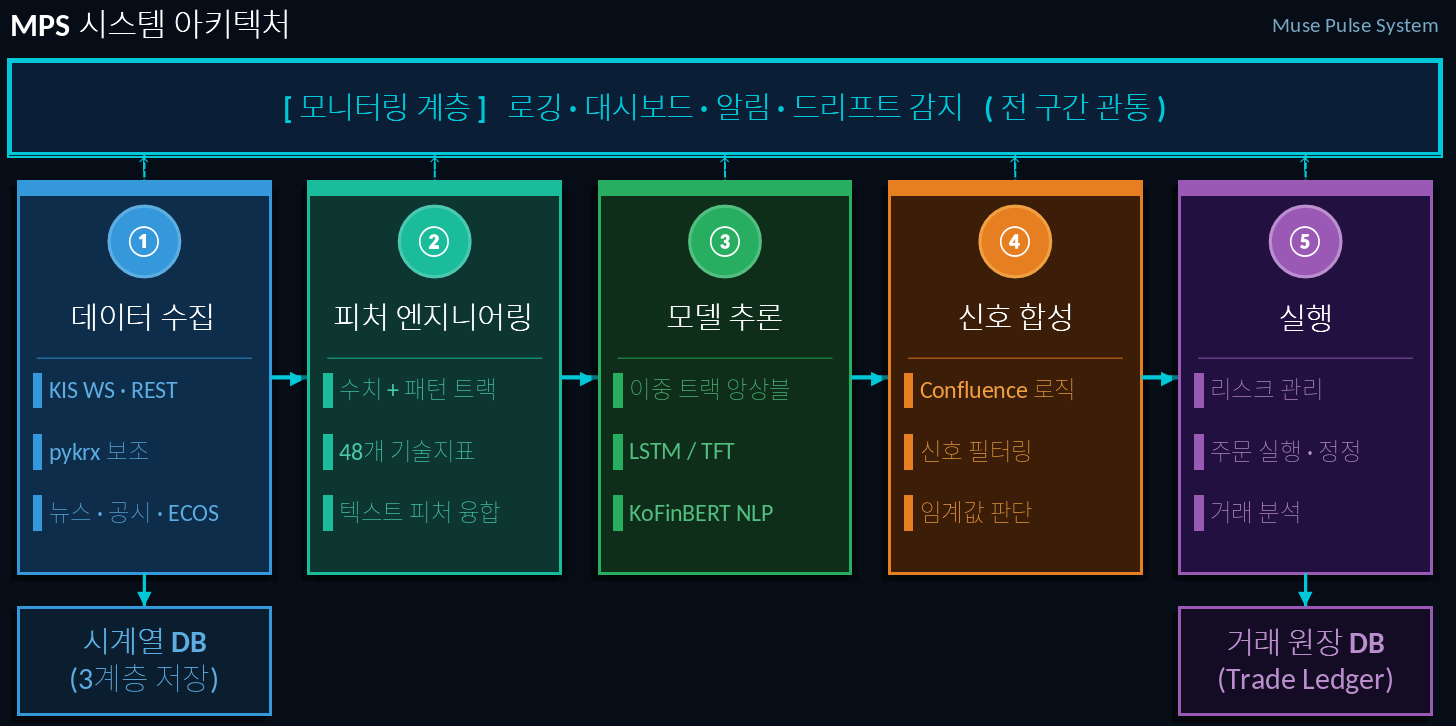

### 컴포넌트 지도

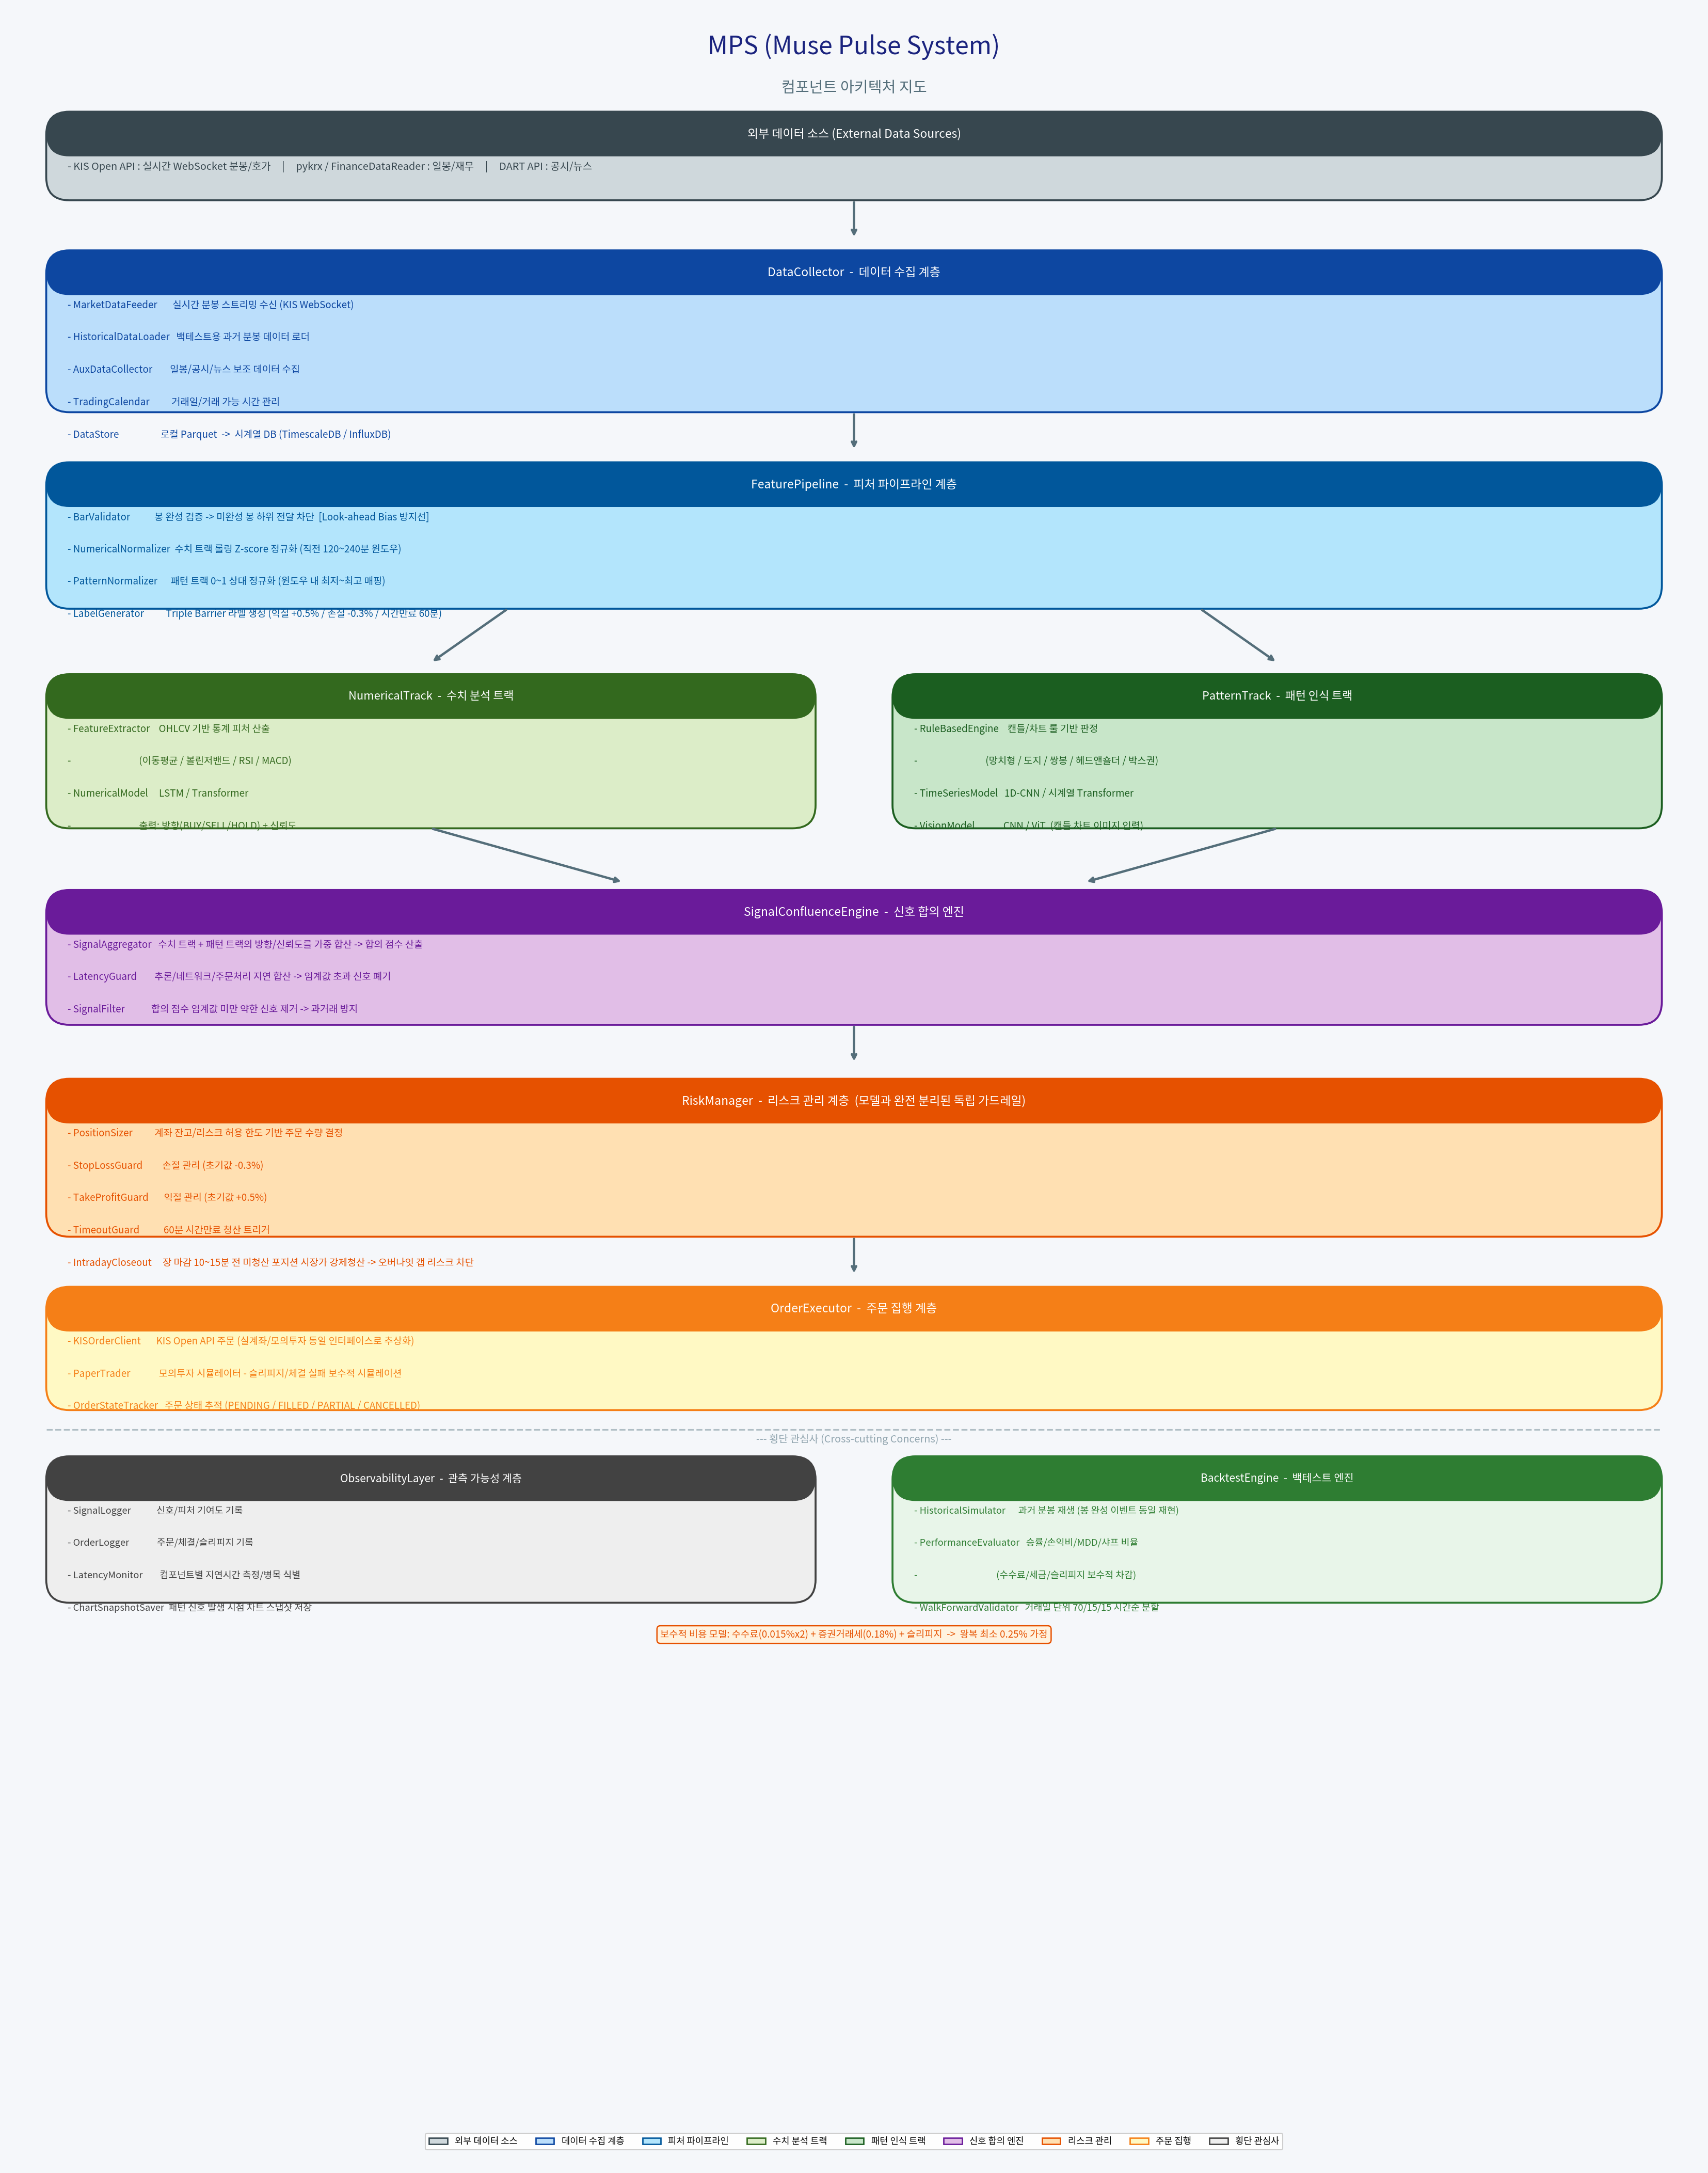

##### 데이터 수집 계층 (Data Ingestion Layer)

시장의 모든 입력을 시스템에 끌어들이는 관문으로, 실시간성과 신뢰성이 핵심

1. **(실시간 분봉 스트리머)** KIS Open API의 Websocket을 구독해 1분봉을 봉 완성 시점에 즉시 수신. 단타 시스템의 가장 중요한 입력원
1. **(호가 스트리머)** 동일 Websocket 채널로 매수·매도 10호가 수신. 슬리피지 추정과 주문 가격 결정에 사용
1. **(보조 데이터 수집기)** pykrx, FinanceDataReader 기반 일봉·기본 정보·재무 데이터 일배치 수집. 중기 추세 맥락 제공
1. **(공시·뉴스 수집기)** DART API와 뉴스 크롤러. 단기 이벤트 트리거에 활용
1. **(거래 캘린더 관리기)** 휴일장·정규장 시간관리, 다른 컴포넌트에 거래 가능 여부 제공
1. **(학습용 과저 데이터 수집기)** KIS REST API 분봉 조회, pykrx 일봉 보완으로 N년치 데이터를 초기 1회 또는 주기적으로 수집. 데이터 레이크의 raw 계층에 적재하며 피처 엔지니어링 파이프라인의 오프라인 학습 입력이 됨.

##### 피처 파이프라인 계층 (Feature Pipeline Layer)

원시 봉 데이터를 두 트랙의 모델 입력 형태로 변환하는 계층

1. **(봉 완성 검증기)** 봉이 완전히 닫힌 시점인지 확인하고 미완성 봉이 하위 컴포넌트로 전달되는 것을 차단. look-ahead bias 방지의 최전선
1. **(수치 정규화기)** 직전 N분 윈도우의 롤링 Z-score 적용. 장중 시간대별 분포 차이를 보정해 "지금 이 시점의 평소 대비 비정상도" 표현
1. **(패턴 정규화기)** 윈도우 내 최저~최고가를 0~1로 매핑하는 상대 정규화. 절대 가격이 아닌 형태가 핵심이므로 종목·가격대와 무관한 패턴 인식 가능하게 함
1. **(라벨 생성기)** Triple Barrier 방식으로 익절선·손절선·시간만료 중 먼저 닿는 것을 라벨로 생성. 초기값: 익절 +0.5%, 손절 -0.3%, 시간만료 60분

##### 수치 분석 트랙 (Numerical Track)

통계적 피처와 시계열 모델로 정량적 매매 신호를 생성하는 트랙

1. **(피처 추출기)** OHLCV 기반 이동평균·볼린저밴드·RSI·MACD 등 통계 피처 산출. 일봉 추세 맥락을 보조 피처로 병합
1. **(수치 모델)** LSTM 또는 Transformer 구조로 120~240분 롤링 Z-score 피처를 입력받아 Triple Barrier 라벨 예측. 출력: 방향(BUY/SELL/HOLD) + 신뢰도

##### 패턴 인식 트랙 (Pattern Track)

차트 형태와 시각적 맥락에서 신호를 추출하는 트랙. 룰 기반과 학습 기반을 병행

1. **(룰 기반 패턴 엔진)** 망치형·도지·장대양봉·쌍봉·헤드앤숄더·박스권 돌파 등 전통 캔들·차트 패턴을 명시적 규칙으로 판정. 해석 가능성이 높고 즉시 작동 가능
1. **(시계열 패턴 모델)** 0~1 상대 정규화된 OHLCV 시계열을 1D-CNN 또는 시계열 Transformer에 입력해 패턴 학습. 가볍고 빠르며 봉의 정확한 수치를 직접 학습
1. **(비전 패턴 모델)** 캔들 차트 이미지를 CNN 또는 ViT에 입력. 인간 트레이더가 보는 것과 동일한 시각적 맥락(추세선·지지저항·거래량 분포)을 입력으로 사용. "차트는 1급 신호원" 원칙 구현

##### 신호 합의 엔진 (Signal Confluence Engine)

두 트랙의 신호를 결합하고 지연시간·신뢰도 필터를 적용하는 계층

1. **(신호 집합기)** 수치 트랙과 패턴 트랙의 방향·신뢰도를 가중 합산해 합의 점수 산출. 두 트랙이 같은 방향을 가리킬 때 신호 강도 가산
1. **(지연시간 가드)** 추론 지연·네트워크 지연·주문 처리 지연을 합산하고 임계값 초과 신호를 폐기. 비전 모델이 수치 모델보다 무거우므로 두 모델의 지연을 별도 측정
1. **(신호 필터)** 합의 점수가 임계값 미만인 약한 신호를 제거해 과거래 방지

##### 리스크 관리 계층 (Risk Manager)

모델·패턴 인식과 완전히 분리된 독립 가드레일. 어떤 모델이 사용되더라도 이 계층이 손실을 통제

1. **(포지션 사이저)** 계좌 잔고와 리스크 허용 한도에 따라 주문 수량 결정
1. **(손절·익절 가드)** Triple Barrier 임계값에 따른 손절(-0.3%)·익절(+0.5%) 관리
1. **(시간만료 가드)** 진입 후 60분 경과 시 방향 무관 청산 트리거
1. **(장중 강제청산)** 장 마감 10~15분 전 미청산 포지션 시장가 강제청산. 오버나잇 갭 리스크 원천 차단
1. **(비용 모델)** 수수료(0.015%×2)·증권거래세(0.18%)·슬리피지를 보수적으로 가정해 왕복 최소 0.25% 비용 기준으로 신호 임계값 설정

##### 주문 집행 계층 (Order Executor)

리스크 관리 계층이 승인한 주문을 실제 API에 전달하는 계층

1. **(KIS 주문 클라이언트)** KIS Open API REST 주문 인터페이스. 실계좌와 모의투자 계좌를 동일 인터페이스로 교체 가능하도록 추상화
1. **(페이퍼 트레이더)** 모의투자 시뮬레이터. 백테스트→모의투자→실계좌 3단계 게이트에서 모의투자 역할 담당. 슬리피지·체결 실패 확률을 보수적으로 시뮬레이션
1. **(주문 상태 추적기)** 주문 ID별 PENDING/FILLED/PARTIAL/CANCELLED 상태 관리. 미체결 주문 재처리 로직 포함

##### 관측 가능성 계층 (Observability Layer)

"블랙박스가 알아서 잘 하겠지"를 허용하지 않는 원칙의 구현체. 모든 컴포넌트가 이 계층을 통해 이벤트를 기록

1. **(신호 로거)** NumericalSignal·PatternSignal·TradeSignal 전부 기록. 어떤 피처가 신호에 기여했는지(feature importance) 포함
1. **(주문 로거)** 주문·체결 내역, 슬리피지, 체결 실패 사유 기록
1. **(지연시간 모니터)** 컴포넌트별 처리 지연을 측정해 병목 구간 식별
1. **(차트 스냅샷 저장기)** 패턴 신호 발생 시점의 차트 이미지를 파일로 보관. 사후 패턴 검증에 사용

##### 백테스트 엔진 (Backtest Engine)

모의투자 게이트 진입 전 첫 번째 검증 단계

1. **(과거 데이터 시뮬레이터)** 로컬 분봉 파일을 재생하며 FeaturePipeline → 두 트랙 → 신호합의 → 리스크관리 → 주문 전 과정을 시뮬레이션. 봉 완성 이벤트 타이밍을 실거래와 동일하게 재현
1. **(성능 평가기)** 승률·손익비·최대낙폭(MDD)·샤프 비율 산출. 수수료·세금·슬리피지를 보수적으로 차감한 순수익 기준 평가
1. **(위크포워드 검증기)** 거래일 단위 70/15/15 시간순 분할로 미래 정보 누출 방지. Walk-Forward 방식으로 학습·검증·테스트 구간을 슬라이딩해 일반화 성능 확인

### 컴포넌트 간 인터페이스

##### 핵심 데이터 구조

각 컴포넌트 간 경계를 흐르는 주요 데이터 타입. 이 구조가 인터페이스 계약의 핵심이며, 컴포넌트 교체 시 이 타입만 유지하면 됨

```python
# 봉 기본 단위 - 시스템 전체의 기본 입력
Bar:
  ticker: str           # 종목 코드
  timestamp: datetime   # 봉 시작 시각
  open, high, low, close: float
  volume: int
  is_complete: bool     # False면 하위 컴포넌트 전달 금지 (look-ahead bias 방지선)
```

##### DataCollector → FeaturePipeline

| 항목 | 내용 |
|------|------|
| 전달 단위 | `Bar` (`is_complete=True` 만 통과) |
| 호출 방식 | 봉 완성 이벤트 트리거 (push) |
| 핵심 계약 | `BarValidator`가 미완성 봉을 차단. 이 경계가 look-ahead bias 방지선 |

##### FeaturePipeline → NumericalTrack

```python
NumericalInput:
  window: np.ndarray    # shape [N, features], rolling Z-score 정규화
  window_size: int      # 120~240분 (결정3)
  ticker: str
  bar_timestamp: datetime
```

##### FeaturePipeline → PatternTrack

```python
PatternInput:
  ohlcv_series: np.ndarray   # shape [N, 5], 0~1 상대 정규화 (결정7)
  chart_image: np.ndarray    # shape [H, W, C], 캔들 차트 이미지 (결정5)
  ticker: str
  bar_timestamp: datetime
```

##### NumericalTrack → SignalConfluenceEngine

```python
NumericalSignal:
  ticker: str
  timestamp: datetime
  direction: Literal["BUY", "SELL", "HOLD"]
  confidence: float          # 0.0~1.0
  feature_contrib: dict      # 피처별 기여도 (관측 가능성 원칙)
  latency_ms: float          # 추론 지연시간
```

##### PatternTrack → SignalConfluenceEngine

```python
PatternSignal:
  ticker: str
  timestamp: datetime
  direction: Literal["BUY", "SELL", "HOLD"]
  confidence: float
  pattern_name: str                            # 예: "hammer", "box_breakout"
  source: Literal["RULE", "CNN", "VISION"]     # 신호 출처
  latency_ms: float
```

##### SignalConfluenceEngine → RiskManager

```python
TradeSignal:
  ticker: str
  timestamp: datetime
  direction: Literal["BUY", "SELL"]
  combined_score: float    # 두 트랙 합의 점수
  num_track_conf: float    # 수치 트랙 신뢰도
  pat_track_conf: float    # 패턴 트랙 신뢰도
  total_latency_ms: float
  # LatencyGuard가 임계값 초과 신호를 여기서 폐기
```

##### RiskManager → OrderExecutor

```python
Order:
  ticker: str
  direction: Literal["BUY", "SELL"]
  quantity: int
  order_type: Literal["MARKET", "LIMIT"]
  price: Optional[float]
  stop_loss: float           # Triple Barrier 손절선 (-0.3% 초기값)
  take_profit: float         # Triple Barrier 익절선 (+0.5% 초기값)
  expire_at: datetime        # 60분 시간만료 또는 마감 강제청산 시각

# 리스크 조건 미충족 시 Order 대신 Reject 반환
Reject:
  reason: str                # "cost_threshold", "latency_exceeded", "position_limit" 등
```

##### OrderExecutor → OrderStateTracker

```python
OrderResult:
  order_id: str
  status: Literal["PENDING", "FILLED", "PARTIAL", "CANCELLED"]
  filled_price: float
  filled_qty: int
  timestamp: datetime
  slippage: float            # 기대가 vs 체결가 차이 기록
```

##### ObservabilityLayer 인터페이스 (횡단)

모든 컴포넌트가 이 Protocol을 통해 이벤트를 emit. 실제 로거 구현체를 교체해도 컴포넌트 코드는 변경 불필요

```python
class ObservabilityPort(Protocol):
    def emit_signal(self, signal: NumericalSignal | PatternSignal | TradeSignal) -> None: ...
    def emit_order(self, order: Order, result: OrderResult) -> None: ...
    def emit_latency(self, component: str, latency_ms: float) -> None: ...
    def save_chart_snapshot(self, ticker: str, timestamp: datetime, image: np.ndarray) -> None: ...
```

### 기술 스택 선택 근거

##### 언어·프레임워크

| 기술 | 선택 근거 |
|------|---------|
| **Python** | ML·퀀트 생태계의 사실상 표준. KIS Open API Python SDK 존재. 빠른 프로토타이핑과 모델 실험이 가능 |
| **PyTorch** | NumericalModel(LSTM/Transformer), TimeSeriesPatternModel(1D-CNN), VisionPatternModel(CNN/ViT) 모두 커스텀 아키텍처 필요 → 연구 단계에서 유연성이 높음 |

##### 데이터 수집·저장

| 기술 | 단계 | 선택 근거 |
|------|------|---------|
| **KIS Open API** | 전 단계 | 결정10 — KOSPI 한정, 분봉 실시간 WebSocket 스트리밍 지원. 개인 자동매매 인프라에서 사실상 유일한 선택지 |
| **pykrx / FinanceDataReader** | 전 단계 | 일봉·기본 정보·재무 데이터 수집용. KIS REST API의 분봉 조회 한계를 보완 |
| **Parquet (로컬 파일)** | 초기 | "반드시 변경될 것" 목록에 명시. 빠른 I/O와 스키마 보존. DataStore 인터페이스 뒤에 격리해 교체 비용 최소화 |
| **TimescaleDB / InfluxDB** | 중기 이후 | "반드시 변경될 것" — 시계열 특화 쿼리(분봉 윈도우 슬라이딩)와 타임스탬프 인덱싱에 최적화 |

##### 피처·정규화

| 기술 | 선택 근거 |
|------|---------|
| **Rolling Z-score (수치 트랙)** | 결정7 — 장중 시간대별 분포 차이 보정. "지금 이 시점의 평소 대비 비정상도"를 표현하는 데 절대 정규화보다 적합 |
| **Min-Max 상대 정규화 (패턴 트랙)** | 결정7 — 패턴 트랙은 절대 가격이 아닌 형태가 핵심. 윈도우 내 상대 위치로 정규화해야 종목·가격대와 무관한 동일 패턴 인식 가능 |
| **Triple Barrier 라벨링** | 결정6 — 방향 분류가 아닌 실거래 구조(익절/손절/시간만료) 그대로 라벨화. 수치·패턴 두 트랙이 동일 라벨을 공유해 신호 결합 시 직접 비교 가능 |

##### 모델

| 기술 | 선택 근거 |
|------|---------|
| **LSTM / Transformer (수치 트랙)** | 결정1·3 — 분봉 시계열의 순서 의존성 모델링. 120~240봉 룩백 윈도우 처리에 적합 |
| **룰 기반 캔들 엔진 (초기 패턴)** | 결정4 — 해석 가능성 높고 즉시 작동. 학습 데이터 없이 신호 후보 생성 가능해 초기 단계 위험 분산 |
| **1D-CNN / 시계열 Transformer** | 결정4·5 — OHLCV 시계열의 형태 학습에 적합. 룰 기반보다 표현력 높고 비전 모델보다 가볍고 빠름 |
| **CNN / ViT (비전 모델)** | 결정5 — "차트는 1급 신호원" 원칙 구현. 인간 트레이더가 보는 시각적 맥락(추세선·지지저항·거래량 분포)을 동일하게 입력 |

##### 신호 합의·검증·배포

| 기술 | 선택 근거 |
|------|---------|
| **가중 평균 → 메타 모델 (단계적)** | 결정2 — 초기에는 단순 결합, 두 트랙 거동 파악 후 학습 기반 메타 결합기로 발전. "변경할 수 있는 것"으로 명시 |
| **지연시간 측정 + 신호 폐기** | 설계 원칙 "지연시간은 곧 비용" — 추론·네트워크·주문 처리 지연을 각각 측정. 합산 임계값 초과 시 해당 신호 폐기. 비전 모델 지연은 별도 관리 |
| **Walk-Forward 검증** | 결정8 — 거래일 단위 70/15/15 시간순 분할로 미래 정보 누출 방지. 무작위 K-fold는 분봉 단위 데이터에서 같은 날 데이터가 학습·검증에 섞여 누출 발생 |
| **백테스트→모의투자→실계좌 3단계 게이트** | 설계 원칙 "Paper Trading First" — 단타는 잘못된 시스템이 짧은 시간에 큰 손실 누적 가능. 각 단계는 승률·손익비·MDD 명시적 승인 기준 통과 필수 |
| **CI/CD (중기 이후)** | 설계 원칙 "재현 가능성" — 데이터·모델·코드 버전이 모두 추적 가능해야 함. "반드시 변경될 것"으로 명시. 초기엔 수동 배포 |